## Calibration eval

In [1]:
from retention_optimizer.preprocessing import encode, split_data
from retention_optimizer.models.churn import (
    build_oof_frame,
    calibration_scores,
    compute_oof,
    load_data,
    load_xgb,
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = load_data('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
customer_id = df['customerID']          # apartado para el bloque C
df_enc = encode(df)
X_train, X_test, y_train, y_test = split_data(df_enc)

In [3]:
xgb = load_xgb('../models/xgb_churn_baseline.joblib')

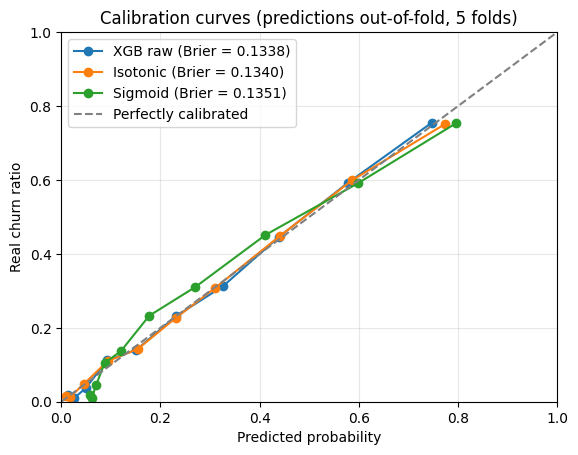

In [5]:
scores = calibration_scores(xgb, X_train, y_train)

for name, r in scores.items():
    plt.plot(r['prob_pred'], r['prob_true'], marker='o',
             label=f"{name} (Brier = {r['brier']:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
         label='Perfectly calibrated')

plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel('Predicted probability')
plt.ylabel('Real churn ratio')
plt.title('Calibration curves (predictions out-of-fold, 5 folds)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

### Decision — keeping the raw XGBoost (no calibration)

**Evidence (OOF predictions on train, `StratifiedKFold(5)`):**

| Estimator | Brier |
|---|---|
| XGB raw  | 0.1338 |
| Isotonic | 0.1340 |
| Sigmoid  | 0.1351 |

- Raw has the lowest Brier of the three, though the gap with isotonic
  (3rd decimal) is noise more than signal — what *is* signal is that
  **no wrapper improves on the base model**.
- On the reliability curve, raw hugs the diagonal across the whole observed
  range. Isotonic tracks it closely (makes sense: starting from an
  already-calibrated model, the best it can do is reproduce it). Sigmoid is
  the only one that deviates systematically — it underpredicts real churn
  in the 0.1–0.45 band — because it imposes a correction shape that isn't
  needed here.
- **The tail diagnostic (p > 0.6) from plan point 3 was not run.** That
  check existed to help decide between isotonic and sigmoid (catching
  whether isotonic produces plateaus of identical p, which would hurt a
  p-based ranking). Since the conclusion is to use neither wrapper, that
  risk doesn't propagate and the check is moot for this decision.

**Why the model already comes calibrated:** the baseline's grid search
converged on a conservative configuration (`max_depth=3`,
`learning_rate=0.03`, `subsample=0.8`) trained with `logloss` on a moderate
class imbalance — the regime where XGBoost doesn't develop the
overconfidence that post-hoc calibration is meant to correct.

**Consequence for block C:** OOF predictions over the full 7,043 customers
are computed with `cross_val_predict` directly on `xgb`, with no
`CalibratedClassifierCV` wrapper — 5 fits instead of 15.

## SHAP — feature attribution

In [6]:
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


SHAP values below are computed on the raw XGBoost fitted on the full train set (not on a calibrated wrapper — `TreeExplainer` needs direct access to the trees). They live in **log-odds (margin) space**: a positive value pushes the prediction toward churn, a negative one away from it, before the sigmoid turns that margin into a probability. Calibration is a monotonic transform of the output, so it cannot change which features drive a prediction or in which direction — the attribution below is valid regardless of the calibration decision above.

In [7]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

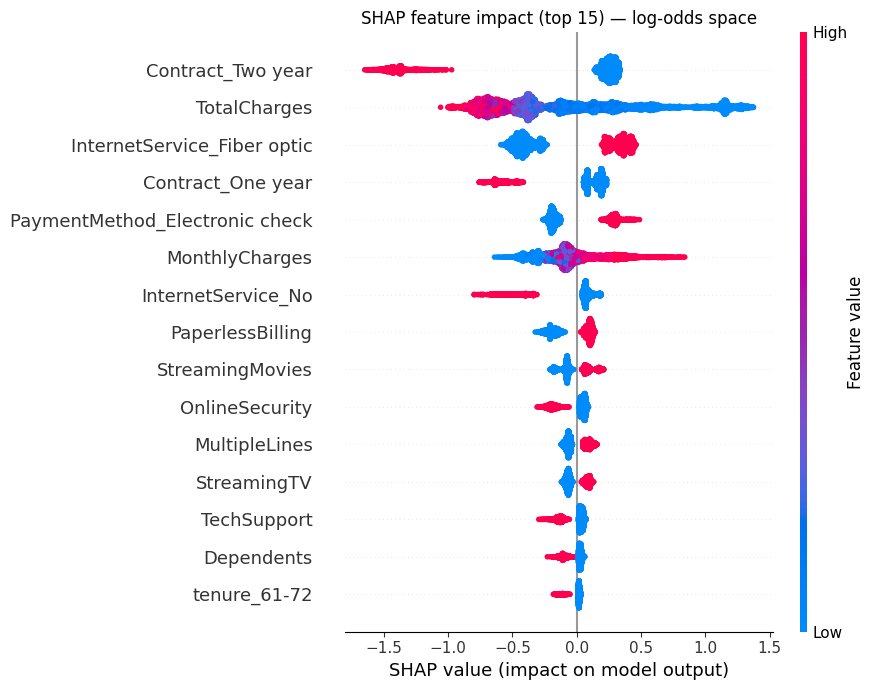

In [8]:
shap.summary_plot(shap_values, X_train, max_display=15, show=False)
plt.title('SHAP feature impact (top 15) — log-odds space')
plt.gcf().set_size_inches(9, 7)
plt.tight_layout()
plt.show()

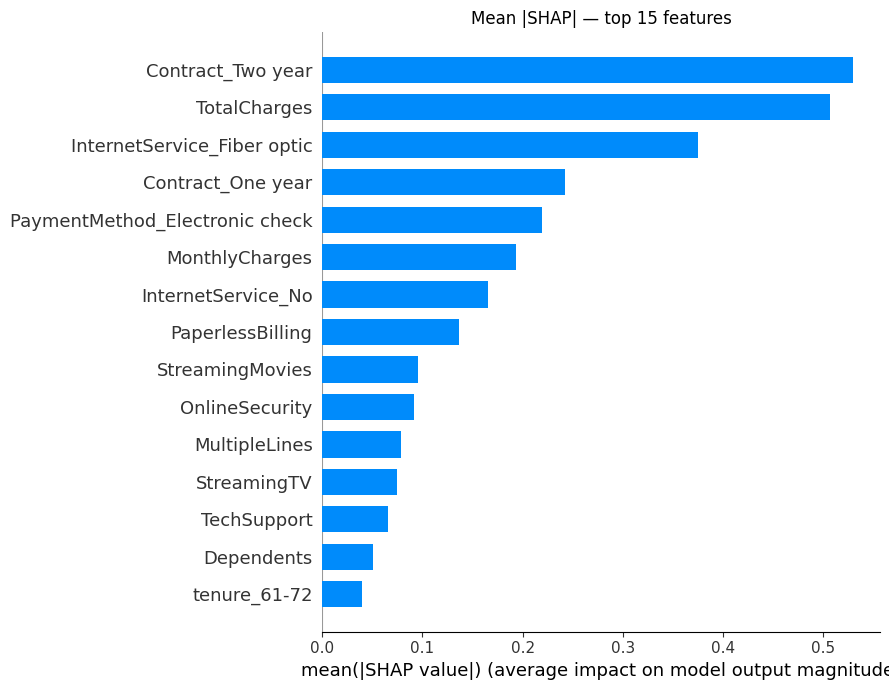

In [9]:
shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| — top 15 features')
plt.gcf().set_size_inches(9, 7)
plt.tight_layout()
plt.show()

**Business insights**

- **Contract length is the single biggest lever on churn risk** — moving a customer from month-to-month onto a one- or two-year contract outweighs any other feature in the model, including price. Migrating month-to-month customers onto longer commitments is the highest-leverage retention action available.
- **Fiber-optic customers are a distinctly higher-risk segment, and it compounds with electronic-check payment and paperless billing** — that combination (fiber + electronic check + paperless) is worth treating as a flagged segment, consistent with a price- or service-quality-driven dissatisfaction story rather than random churn.
- **Among customers who have internet, skipping protective add-ons (security, tech support) reads as higher risk — but the insight is about internet-service posture, not the individual add-on.** The six add-on columns are structurally zero for every customer with no internet at all, and that "no internet" segment is itself one of the lowest-risk groups in the data; the same 0 value means opposite things for a fiber customer who declined the add-on and a customer who never had internet to add it to. The actionable read is "engage internet customers on bare-bones service," not "add-on X causes churn."

## OOF predictions — full dataset (7,043 customers)

`X_full` / `y_full` are just `df_enc` split the other way: `encode()` ran once on all 7,043 rows before the train/test split, so the column set is already identical to `X_train` — no re-encoding needed. Per the calibration decision above, OOF predictions use the raw `xgb` directly, with no `CalibratedClassifierCV` wrapper (5 fits, not 15).

In [10]:
X_full = df_enc.drop(columns='Churn')
y_full = df_enc['Churn']

assert list(X_full.columns) == list(X_train.columns), 'column mismatch between full and train'

In [11]:
p_oof = compute_oof(xgb, X_full, y_full)

In [12]:
oof_df = build_oof_frame(customer_id, p_oof, df_enc)

oof_df.to_csv('../data/processed/oof_predictions.csv', index=False)
oof_df.head()

,customerID,p_oof,MonthlyCharges
0,7590-VHVEG,0.738075,29.85
1,5575-GNVDE,0.044292,56.95
2,3668-QPYBK,0.394004,53.85
3,7795-CFOCW,0.062009,42.30
4,9237-HQITU,0.668406,70.70


Model-quality metrics come from the 80/20 test split; the probabilities that feed the business decision come from OOF over the entire dataset, where no row was predicted by a model that had seen it.

## CLV, VaR and the go/no-go check

`CLV` treats `p_oof` as a constant monthly hazard and values the customer as an annuity: `r = (1 - p) / (1 + d)`, `CLV = MonthlyCharges * r * (1 - r**H) / (1 - r)`, with `d = 0.01` monthly. We compare three variants side by side — infinite horizon, `H = 24`, `H = 36` — as a sensitivity check: an infinite horizon caps CLV at `MonthlyCharges / d` (100 months of billing) for a near-zero-risk customer, which is an aggressive assumption; a finite planning window is more defensible. "VaR" here means the model's **expected loss** (`p * CLV`), not a quantile Value-at-Risk — worth naming explicitly since the term usually means something more specific in risk management.

In [13]:
d = 0.01  # monthly discount rate, shared across every CLV/VaR variant below

oof_df['CLV_inf'] = oof_df['MonthlyCharges'] * (1 - oof_df['p_oof']) / (oof_df['p_oof'] + d)
oof_df['VaR_inf'] = oof_df['p_oof'] * oof_df['CLV_inf']

oof_df[['p_oof', 'MonthlyCharges', 'CLV_inf', 'VaR_inf']].describe()

,p_oof,MonthlyCharges,CLV_inf,VaR_inf
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265368,64.761692,540.727246,39.677145
std,0.241760,30.090047,697.236294,22.600827
min,0.007560,18.250000,5.641188,4.585341
25%,0.051308,35.500000,78.052402,17.301537
50%,0.188032,70.350000,234.532452,37.669041
75%,0.444245,89.850000,767.579451,55.434378
max,0.911191,118.750000,3717.120730,96.792692


In [14]:
horizons = [24, 36]

for H in horizons:
    r = (1 - oof_df['p_oof']) / (1 + d)
    oof_df[f'CLV_H{H}'] = oof_df['MonthlyCharges'] * r * (1 - r**H) / (1 - r)
    oof_df[f'VaR_H{H}'] = oof_df['p_oof'] * oof_df[f'CLV_H{H}']

oof_df[['p_oof', 'MonthlyCharges', 'CLV_H24', 'VaR_H24', 'CLV_H36', 'VaR_H36']].describe()

,p_oof,MonthlyCharges,CLV_H24,VaR_H24,CLV_H36,VaR_H36
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265368,64.761692,361.756850,35.384408,419.797843,37.140028
std,0.241760,30.090047,383.557147,22.040933,476.829548,22.499828
min,0.007560,18.250000,5.641188,2.980027,5.641188,4.060664
25%,0.051308,35.500000,78.022661,15.824044,78.041208,16.494549
50%,0.188032,70.350000,226.402164,32.370844,231.239258,34.492653
75%,0.444245,89.850000,461.346057,50.989094,536.932168,52.551571
max,0.911191,118.750000,1664.484226,92.621660,2163.067155,94.256634


In [15]:
top10_p = oof_df.nlargest(10, 'p_oof')

for H in horizons:
    var_col = f'VaR_H{H}'
    top10_var = oof_df.nlargest(10, var_col)

    print(f'--- H={H} ---')
    print(f'Top 10 customers by {var_col}:')
    display(top10_var[['customerID', 'p_oof', 'MonthlyCharges', f'CLV_H{H}', var_col]])

    overlap_10 = set(top10_p['customerID']) & set(top10_var['customerID'])
    assert len(overlap_10) < 10, (
        f'Top-10 by {var_col} is identical to top-10 by p_oof — VaR should not be '
        'monotonic in p, this points at a bug.'
    )
    print(f'Top-10 by {var_col} overlaps with top-10 by p_oof on {len(overlap_10)}/10 '
          'customers.\n')

--- H=24 ---
Top 10 customers by VaR_H24:


,customerID,p_oof,MonthlyCharges,CLV_H24,VaR_H24
5127,8199-ZLLSA,0.155643,118.35,595.089005,92.621660
4610,2889-FPWRM,0.163860,117.80,560.449919,91.835053
3299,4282-MSACW,0.165155,117.20,552.831617,91.303083
3908,8261-GWDBQ,0.122581,116.05,741.795371,90.930304
1306,0201-OAMXR,0.137759,115.55,659.141328,90.802925
5289,3642-GKTCT,0.136208,115.10,664.064307,90.450583
2146,8894-JVDCV,0.146904,115.05,614.657973,90.295545
4627,3680-CTHUH,0.176789,116.60,510.079679,90.176431
4804,5734-EJKXG,0.201470,118.60,446.251720,89.906156
5009,0052-DCKON,0.177699,115.80,503.665094,89.500708


Top-10 by VaR_H24 overlaps with top-10 by p_oof on 0/10 customers.

--- H=36 ---
Top 10 customers by VaR_H36:


,customerID,p_oof,MonthlyCharges,CLV_H36,VaR_H36
6118,9924-JPRMC,0.087179,118.20,1081.188339,94.256634
5127,8199-ZLLSA,0.155643,118.35,602.327034,93.748212
3908,8261-GWDBQ,0.122581,116.05,763.170184,93.550458
4807,9695-IDRZR,0.097093,116.15,961.953159,93.398568
4610,2889-FPWRM,0.163860,117.80,565.903733,92.728712
1306,0201-OAMXR,0.137759,115.55,672.015022,92.576398
5289,3642-GKTCT,0.136208,115.10,677.567733,92.289851
3299,4282-MSACW,0.165155,117.20,558.023739,92.160590
2146,8894-JVDCV,0.146904,115.05,624.100301,91.682658
4600,1741-WTPON,0.080491,115.85,1137.071727,91.524488


Top-10 by VaR_H36 overlaps with top-10 by p_oof on 0/10 customers.



In [16]:
overlap_rows = []
for H in horizons:
    var_col = f'VaR_H{H}'
    for k in [250, 500, 1000]:
        top_p_k = set(oof_df.nlargest(k, 'p_oof')['customerID'])
        top_var_k = set(oof_df.nlargest(k, var_col)['customerID'])
        overlap_rows.append({'H': H, 'k': k, 'overlap': len(top_p_k & top_var_k) / k})

overlap_table = pd.DataFrame(overlap_rows).pivot(index='k', columns='H', values='overlap')
overlap_table.columns = [f'H={H}' for H in overlap_table.columns]
overlap_table = overlap_table.map(lambda x: f'{x:.1%}')
overlap_table

,H=24,H=36
k,,
250,0.0%,0.0%
500,0.0%,0.0%
1000,0.0%,0.0%


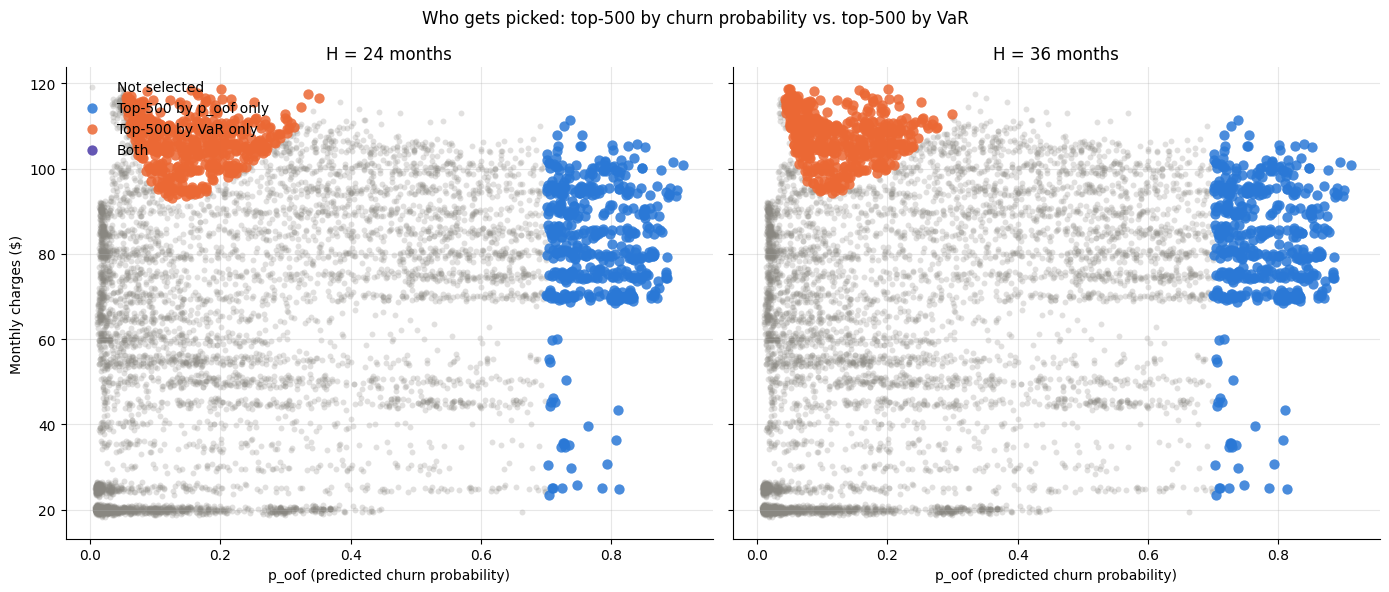

In [17]:
k = 500  # middle of the three k's checked above

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, H in zip(axes, horizons):
    var_col = f'VaR_H{H}'
    top_p_set = set(oof_df.nlargest(k, 'p_oof')['customerID'])
    top_var_set = set(oof_df.nlargest(k, var_col)['customerID'])

    only_p = oof_df[oof_df['customerID'].isin(top_p_set - top_var_set)]
    only_var = oof_df[oof_df['customerID'].isin(top_var_set - top_p_set)]
    both = oof_df[oof_df['customerID'].isin(top_p_set & top_var_set)]
    neither = oof_df[~oof_df['customerID'].isin(top_p_set | top_var_set)]

    ax.scatter(neither['p_oof'], neither['MonthlyCharges'], s=18, c='#898781',
               alpha=0.25, linewidths=0, label='Not selected', zorder=1)
    ax.scatter(only_p['p_oof'], only_p['MonthlyCharges'], s=55, c='#2a78d6',
               alpha=0.85, linewidths=0, label=f'Top-{k} by p_oof only', zorder=2)
    ax.scatter(only_var['p_oof'], only_var['MonthlyCharges'], s=55, c='#eb6834',
               alpha=0.85, linewidths=0, label=f'Top-{k} by VaR only', zorder=2)
    ax.scatter(both['p_oof'], both['MonthlyCharges'], s=55, c='#4a3aa7',
               alpha=0.85, linewidths=0, label='Both', zorder=3)

    ax.set_xlabel('p_oof (predicted churn probability)')
    ax.set_title(f'H = {H} months')
    ax.grid(alpha=0.3, linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Monthly charges ($)')
axes[0].legend(loc='upper left', frameon=False)
fig.suptitle(f'Who gets picked: top-{k} by churn probability vs. top-{k} by VaR')

plt.tight_layout()
plt.show()

## Corrected value criterion: `priority_score` replaces VaR

`VaR = p · CLV` double-counts survival: `CLV` already discounts by `(1 - p)` (a lower churn probability already means a longer, more valuable expected relationship), so multiplying by `p` again rewards a customer both for staying *and* for leaving at the same time. That's why `VaR`'s maximum sits at p≈0.09 regardless of horizon — an artifact of the formula, not a business signal — and, as shown above, it survives the horizon change from infinite to `H=24`/`H=36`, which confirms the horizon was never the problem.

The corrected criterion starts from the expected value of a retention action, `P(churn) · effectiveness · value_retained`. Both `effectiveness` (of whatever intervention S3 designs) and the planning horizon are constants shared across every customer, so they drop out of the **ranking** — only `value_retained` needs a customer-specific number, and it must not itself be re-discounted by the same `p` we're already weighting by (saving the customer is precisely what changes that `p`). We use `MonthlyCharges` as that value proxy: `priority_score = p_oof * MonthlyCharges` is the term that survives once the ranking-irrelevant constants drop out — a **ranking proxy, not a euro-denominated expected value**. The real expected-value calculation (`p · effectiveness · value_retained`, in euros) is S4's job. The `VaR` variants above (infinite, H=24, H=36) are kept unmodified for the narrative — this section replaces them as the criterion going forward, not the record of how we got here.

In [18]:
oof_df['priority_score'] = oof_df['p_oof'] * oof_df['MonthlyCharges']

oof_df[['p_oof', 'MonthlyCharges', 'priority_score']].describe()

,p_oof,MonthlyCharges,priority_score
count,7043.000000,7043.000000,7043.000000
mean,0.265368,64.761692,19.677276
std,0.241760,30.090047,20.901513
min,0.007560,18.250000,0.153471
25%,0.051308,35.500000,2.319527
50%,0.188032,70.350000,10.395829
75%,0.444245,89.850000,33.229160
max,0.911191,118.750000,91.848100


In [19]:
top10_priority = oof_df.nlargest(10, 'priority_score')
print('Top 10 customers by priority_score = p_oof * MonthlyCharges:')
display(top10_priority[['customerID', 'p_oof', 'MonthlyCharges', 'priority_score']])

Top 10 customers by priority_score = p_oof * MonthlyCharges:


,customerID,p_oof,MonthlyCharges,priority_score
2208,7216-EWTRS,0.911191,100.80,91.848100
6482,5419-JPRRN,0.895575,101.45,90.856058
5933,6496-SLWHQ,0.852519,105.00,89.514486
6894,1400-MMYXY,0.840297,105.90,88.987438
1704,0107-YHINA,0.875964,99.75,87.377425
3956,4587-VVTOX,0.826058,105.30,86.983929
3380,5178-LMXOP,0.900742,95.10,85.660569
2246,7181-BQYBV,0.835035,102.45,85.549369
6866,0295-PPHDO,0.890430,95.45,84.991541
4459,3178-FESZO,0.847699,100.25,84.981799


In [20]:
priority_overlap_rows = []
for k in [250, 500, 1000]:
    top_p_k = set(oof_df.nlargest(k, 'p_oof')['customerID'])
    top_priority_k = set(oof_df.nlargest(k, 'priority_score')['customerID'])
    priority_overlap_rows.append({'k': k, 'overlap': len(top_p_k & top_priority_k) / k})

priority_overlap_table = pd.DataFrame(priority_overlap_rows).set_index('k')
priority_overlap_table['overlap'] = priority_overlap_table['overlap'].map(lambda x: f'{x:.1%}')
priority_overlap_table

,overlap
k,
250,54.8%
500,72.8%
1000,79.4%


In [21]:
definitions = {
    'VaR (infinite, p·CLV)': 'VaR_inf',
    'VaR (H=24, p·CLV)': 'VaR_H24',
    'VaR (H=36, p·CLV)': 'VaR_H36',
    'priority_score = p·MonthlyCharges (corrected)': 'priority_score',
}
top_p_by_k = {k: set(oof_df.nlargest(k, 'p_oof')['customerID']) for k in [250, 500, 1000]}

comparison_rows = []
for label, col in definitions.items():
    row = {'definition': label}
    for k in [250, 500, 1000]:
        top_col_k = set(oof_df.nlargest(k, col)['customerID'])
        row[f'k={k}'] = len(top_p_by_k[k] & top_col_k) / k
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows).set_index('definition')
comparison_table = comparison_table.map(lambda x: f'{x:.1%}')
comparison_table

,k=250,k=500,k=1000
definition,,,
"VaR (infinite, p·CLV)",0.0%,0.0%,0.0%
"VaR (H=24, p·CLV)",0.0%,0.0%,0.0%
"VaR (H=36, p·CLV)",0.0%,0.0%,0.0%
priority_score = p·MonthlyCharges (corrected),54.8%,72.8%,79.4%


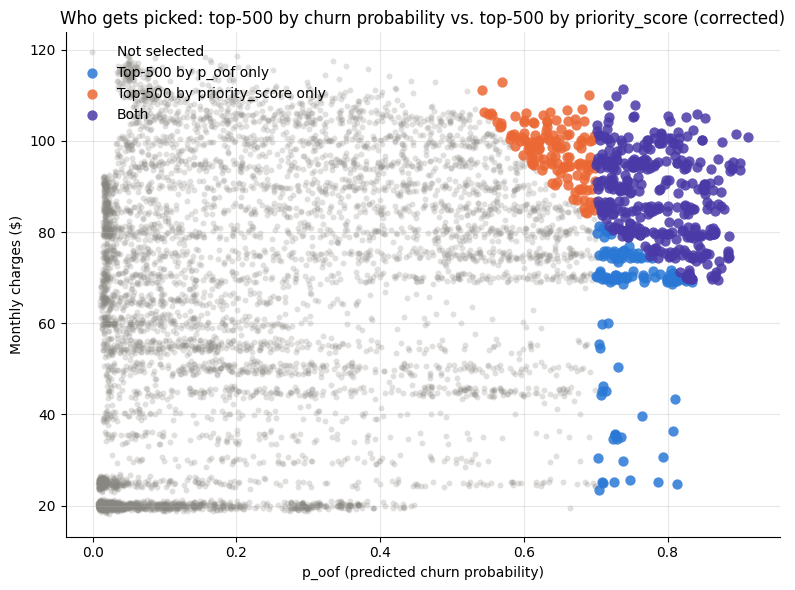

In [22]:
k = 500

top_p_set = set(oof_df.nlargest(k, 'p_oof')['customerID'])
top_priority_set = set(oof_df.nlargest(k, 'priority_score')['customerID'])

only_p = oof_df[oof_df['customerID'].isin(top_p_set - top_priority_set)]
only_priority = oof_df[oof_df['customerID'].isin(top_priority_set - top_p_set)]
both = oof_df[oof_df['customerID'].isin(top_p_set & top_priority_set)]
neither = oof_df[~oof_df['customerID'].isin(top_p_set | top_priority_set)]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(neither['p_oof'], neither['MonthlyCharges'], s=18, c='#898781',
           alpha=0.25, linewidths=0, label='Not selected', zorder=1)
ax.scatter(only_p['p_oof'], only_p['MonthlyCharges'], s=55, c='#2a78d6',
           alpha=0.85, linewidths=0, label=f'Top-{k} by p_oof only', zorder=2)
ax.scatter(only_priority['p_oof'], only_priority['MonthlyCharges'], s=55, c='#eb6834',
           alpha=0.85, linewidths=0, label=f'Top-{k} by priority_score only', zorder=2)
ax.scatter(both['p_oof'], both['MonthlyCharges'], s=55, c='#4a3aa7',
           alpha=0.85, linewidths=0, label='Both', zorder=3)

ax.set_xlabel('p_oof (predicted churn probability)')
ax.set_ylabel('Monthly charges ($)')
ax.set_title(f'Who gets picked: top-{k} by churn probability vs. top-{k} by priority_score (corrected)')
ax.grid(alpha=0.3, linewidth=0.8)
ax.legend(loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()